成功载入特征大表，当前时序截止到: 2024-12-31
尺度 T1 = 0.25 年 批量理论定价完成。
尺度 T1 = 0.5 年 批量理论定价完成。
尺度 T1 = 0.75 年 批量理论定价完成。


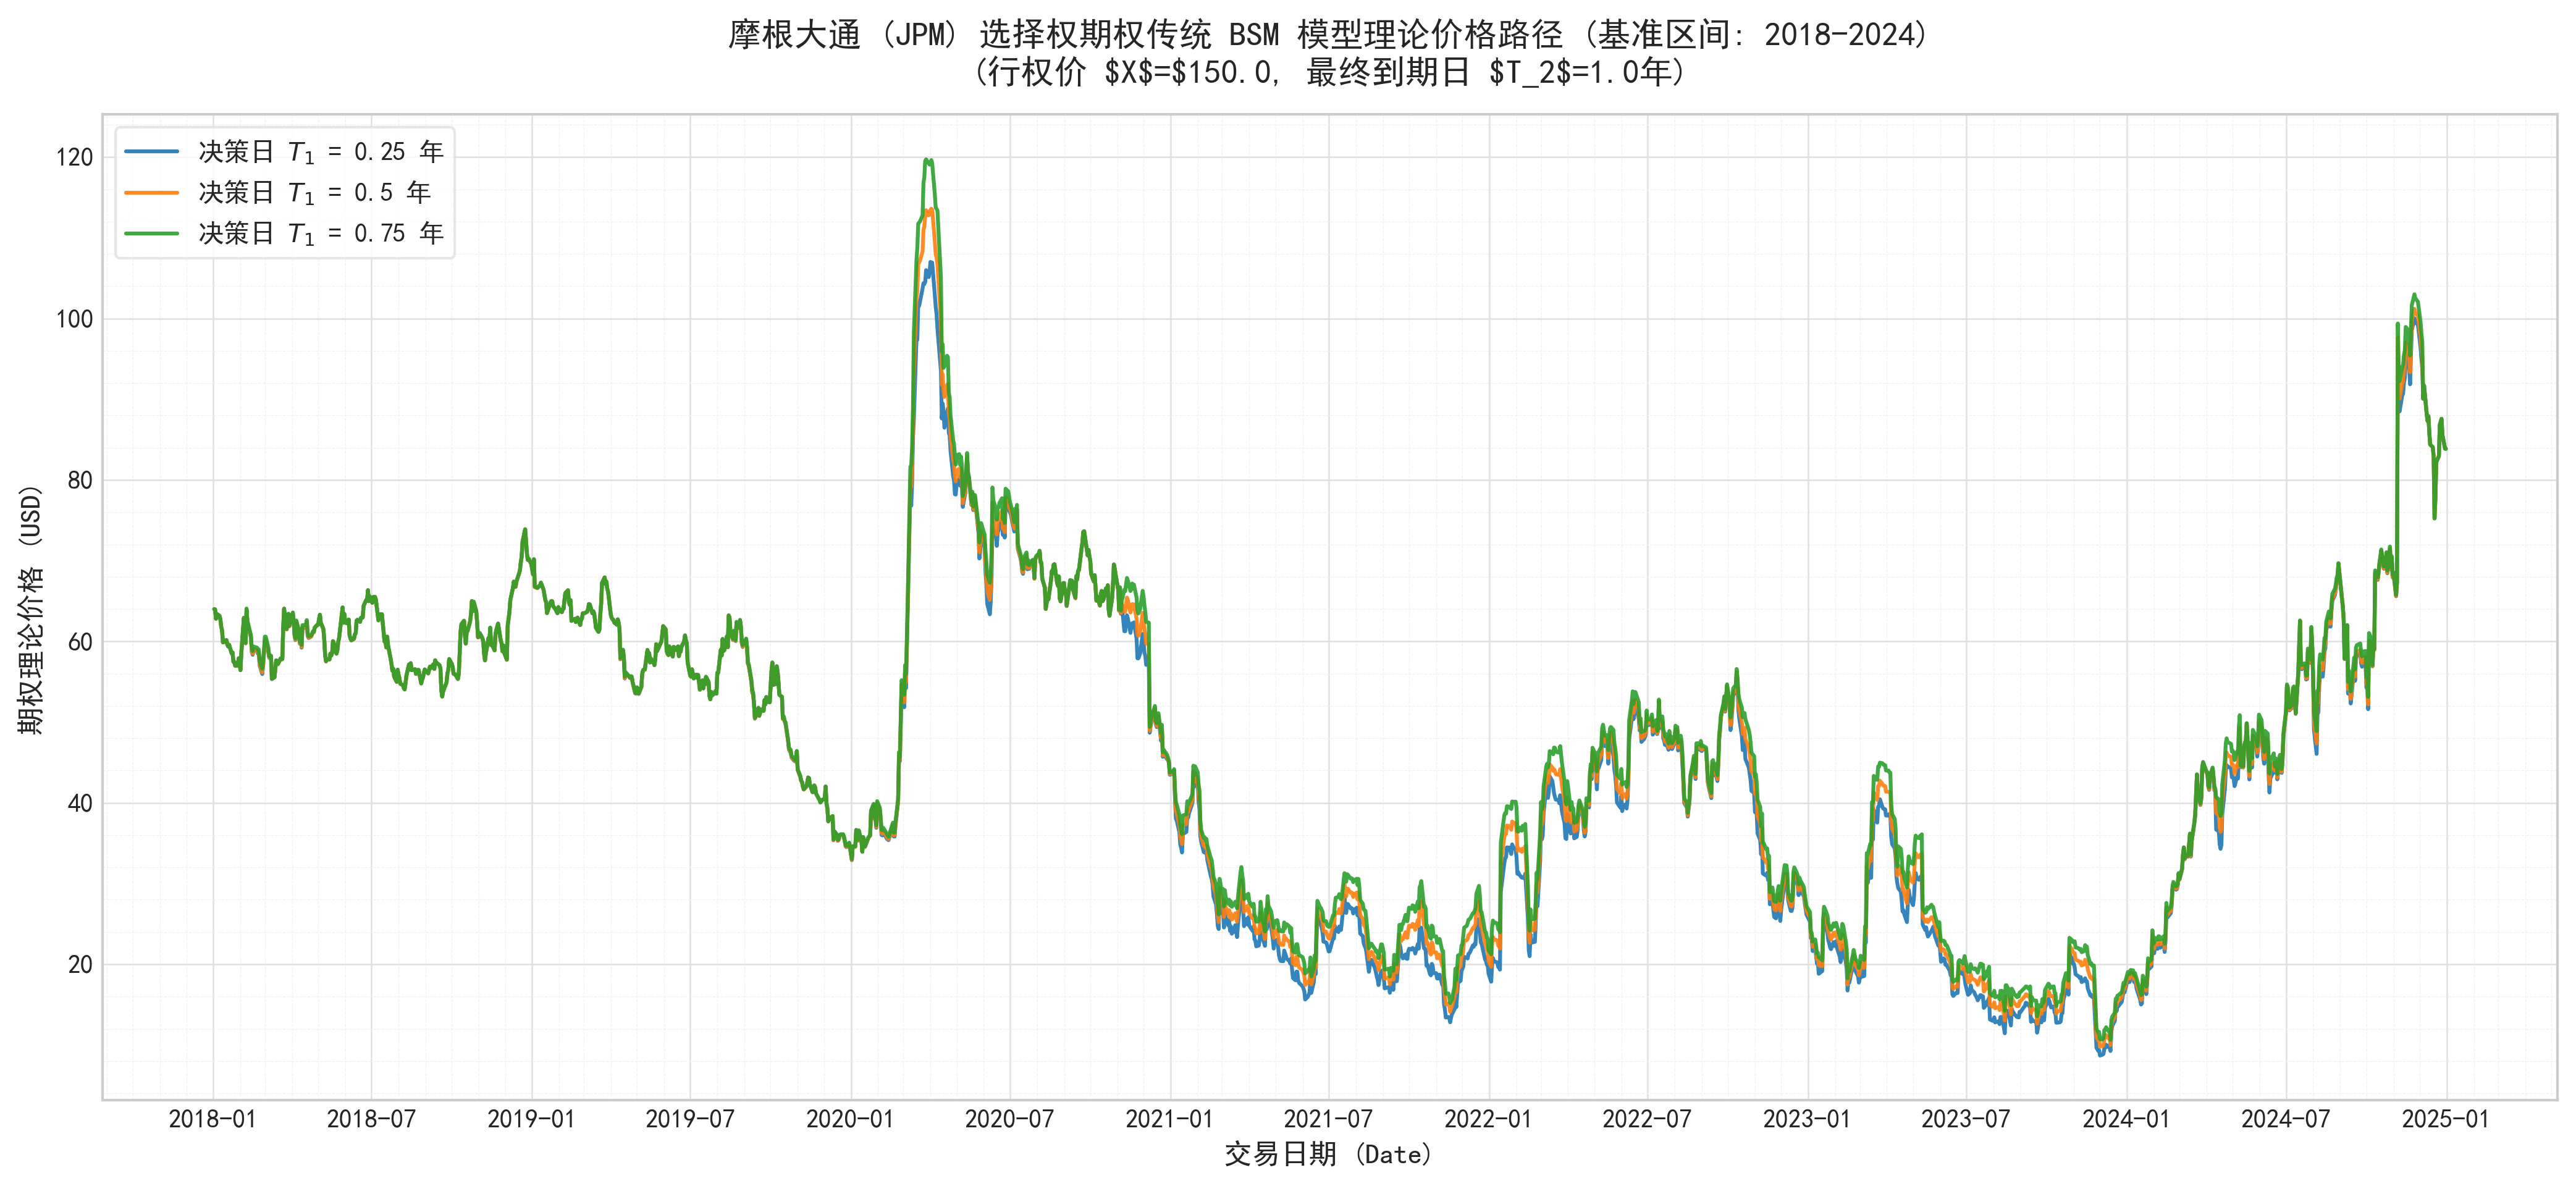

 2018-2024 精细化趋势图已成功导出至: D:\Git\Advanced-Chooser-Option-Pricing-Model-with-Real-World-Data-Machine-Learning\notebooks\reports\figures\week3_t1_sensitivity_scan_2018_2024.png
包含 BSM 基准价格的 2018-2024 训练级特征表已导出成功。


In [ ]:
# 单元格 1: 导入所需量化生态库与定价器
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. 导入本地量化工程模块了
import matplotlib.pyplot as plt
from src.models.bsm_chooser import BsmChooserPricer
# 配置中文字体与绘图美化
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 单元格 2: 读取配置参数与特征大表
config_path = project_root / "config" / "parameters.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

STRIKE = config["fixed_parameters"]["strike_price"]            # 行权价 $150
FINAL_EXPIRY_T2 = config["fixed_parameters"]["final_expiration_t2"] # 到期日 1年
T1_SCALES = config["sensitivity_analysis_settings"]["choice_dates_t1_array"] # [0.25, 0.5, 0.75]

data_path = project_root / "data" / "processed" / "features_ann_final.csv"
df_raw = pd.read_csv(data_path, parse_dates=['Date']).set_index('Date')
df = df_raw.loc['2018-01-01':'2024-12-31'].copy()
print(f"成功载入特征大表，当前时序截止到: {df.index.max().strftime('%Y-%m-%d')}")
# 建立 JPM 2017-2024 完整历史实际除息日程表 (Ex-Dividend Calendar)
jpm_div_schedule = [
    ("2017-01-04", 0.48), ("2017-04-04", 0.50), ("2017-07-03", 0.50), ("2017-10-05", 0.56),
    ("2018-01-04", 0.56), ("2018-04-05", 0.56), ("2018-07-05", 0.56), ("2018-10-04", 0.80),
    ("2019-01-03", 0.80), ("2019-04-04", 0.80), ("2019-07-03", 0.80), ("2019-10-03", 0.90),
    ("2020-01-03", 0.90), ("2020-04-03", 0.90), ("2020-07-02", 0.90), ("2020-10-05", 0.90),
    ("2021-01-05", 0.90), ("2021-04-05", 0.90), ("2021-07-02", 0.90), ("2021-10-05", 1.00),
    ("2022-01-05", 1.00), ("2022-04-05", 1.00), ("2022-07-05", 1.00), ("2022-10-05", 1.00),
    ("2023-01-05", 1.00), ("2023-04-05", 1.00), ("2023-07-05", 1.00), ("2023-10-05", 1.05),
    ("2024-01-04", 1.05), ("2024-04-03", 1.15), ("2024-07-04", 1.15), ("2024-10-03", 1.25)
]
df_div = pd.DataFrame(jpm_div_schedule, columns=['Date', 'Amount'])
df_div['Date'] = pd.to_datetime(df_div['Date'])

# 动态提取并拼装：每一天往前推 365 天窗口内的派息总额
rolling_div_sums = []
for current_date in df.index:
    valid_divs = df_div[(df_div['Date'] <= current_date) & (df_div['Date'] > current_date - pd.Timedelta(days=365))]
    rolling_div_sums.append(valid_divs['Amount'].sum())

# 将动态滚动股息率保存为 Real_Dividend_Yield 特征列，实现无套利匹配
df['Real_Dividend_Yield'] = np.array(rolling_div_sums) / df['JPM_Close']
# 单元格 3: 多尺度向量化批量定价扫描
pricer = BsmChooserPricer()

for t1 in T1_SCALES:
    column_name = f"Chooser_BSM_T1_{t1}"
    # 向量化传入真实世界特征流：JPM价格、无风险利率、20日历史实现波动率、长期分红趋势
    df[column_name] = pricer.price_chooser(
        s0=df['JPM_Close'].values,
        strike=STRIKE,
        t1=t1,
        t2=FINAL_EXPIRY_T2,
        r=df['Risk_Free_Rate'].values,
        q=df['Real_Dividend_Yield'].values,
        sigma=df['Rolling_Vol_20d'].values
    )
    print(f"尺度 T1 = {t1} 年 批量理论定价完成。")

# 单元格 4: 生成多尺度期权溢价历史路径对比图
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(14, 6.5), dpi=300) # 300 DPI 超清印刷级渲染

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for t1, col in zip(T1_SCALES, colors):
    ax.plot(df.index, df[f"Chooser_BSM_T1_{t1}"], label=f"决策日 $T_1$ = {t1} 年", color=col, linewidth=1.5, alpha=0.9)

# 装饰器精细化配置
ax.set_title(f"摩根大通 (JPM) 选择权期权传统 BSM 模型理论价格路径 (基准区间: 2018-2024)\n(行权价 $X$=${STRIKE}, 最终到期日 $T_2$={FINAL_EXPIRY_T2}年)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("交易日期 (Date)", fontsize=11)
ax.set_ylabel("期权理论价格 (USD)", fontsize=11)
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#e0e0e0", fontsize=10)

# 配置横轴细密时间刻度：主刻度按半年划分，次刻度按月划分
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

# 配置纵轴次级细密网格
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# 开启极细双重网格线
ax.grid(True, which='major', linestyle='-', linewidth=0.6, color='#e0e0e0')
ax.grid(True, which='minor', linestyle='--', linewidth=0.3, color='#f0f0f0')

plt.tight_layout()

# 保存契合报告标准的超清图片
output_fig_path = project_root / "notebooks" / "reports" / "figures" / "week3_t1_sensitivity_scan_2018_2024.png"
output_fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_fig_path, bbox_inches='tight', dpi=300)
plt.show()

print(f" 2018-2024 精细化趋势图已成功导出至: {output_fig_path}")

# 单元格 5: 导出带有传统 BSM 基准数据的全新特征表，为后续机器学习机器学习训练喂料
df.to_csv(f"{project_root}/data/processed/features_with_bsm_baseline.csv")
print("包含 BSM 基准价格的 2018-2024 训练级特征表已导出成功。")

In [11]:
# 单元格 6: 2018-2024 全量时序数学边界校验

# 1. 检查在 2018-2024 区间内，T1=0.5 是否有任何一天比 T1=0.25 还要便宜？
cross_error_1 = df[df['Chooser_BSM_T1_0.5'] < df['Chooser_BSM_T1_0.25']]

# 2. 检查在 2018-2024 区间内，T1=0.75 是否有任何一天比 T1=0.5 还要便宜？
cross_error_2 = df[df['Chooser_BSM_T1_0.75'] < df['Chooser_BSM_T1_0.5']]

print(f" [2018-2024 ] T1=0.25 与 T1=0.50 发生逻辑交叉的交易日天数: {len(cross_error_1)} 天")
print(f" [2018-2024 ] T1=0.50 与 T1=0.75 发生逻辑交叉的交易日天数: {len(cross_error_2)} 天")

if len(cross_error_1) == 0 and len(cross_error_2) == 0:
    print("\n 验证成功：在 2018-2024 的 7 年时序（约 1760 个交易日）中，模型满足选择权单调递增边界！")
    print("数学上无任何交叉现象。")
else:
    print("\n 警告：在 2018-2024 范围内检测到异常交叉点！请审查以下异常快照：")
    if not cross_error_1.empty:
        print("\n[错误样本快照] T1_0.5 < T1_0.25:")
        print(cross_error_1[['JPM_Close', 'Rolling_Vol_20d', 'Chooser_BSM_T1_0.25', 'Chooser_BSM_T1_0.5']].head())
    if not cross_error_2.empty:
        print("\n[错误样本快照] T1_0.75 < T1_0.5:")
        print(cross_error_2[['JPM_Close', 'Rolling_Vol_20d', 'Chooser_BSM_T1_0.5', 'Chooser_BSM_T1_0.75']].head())

 [2018-2024 ] T1=0.25 与 T1=0.50 发生逻辑交叉的交易日天数: 0 天
 [2018-2024 ] T1=0.50 与 T1=0.75 发生逻辑交叉的交易日天数: 0 天

 验证成功：在 2018-2024 的 7 年时序（约 1760 个交易日）中，模型满足选择权单调递增边界！
数学上无任何交叉现象。


 已成功锁定年度扫描队列（共 7 年）: [2018, 2019, 2020, 2021, 2022, 2023, 2024]


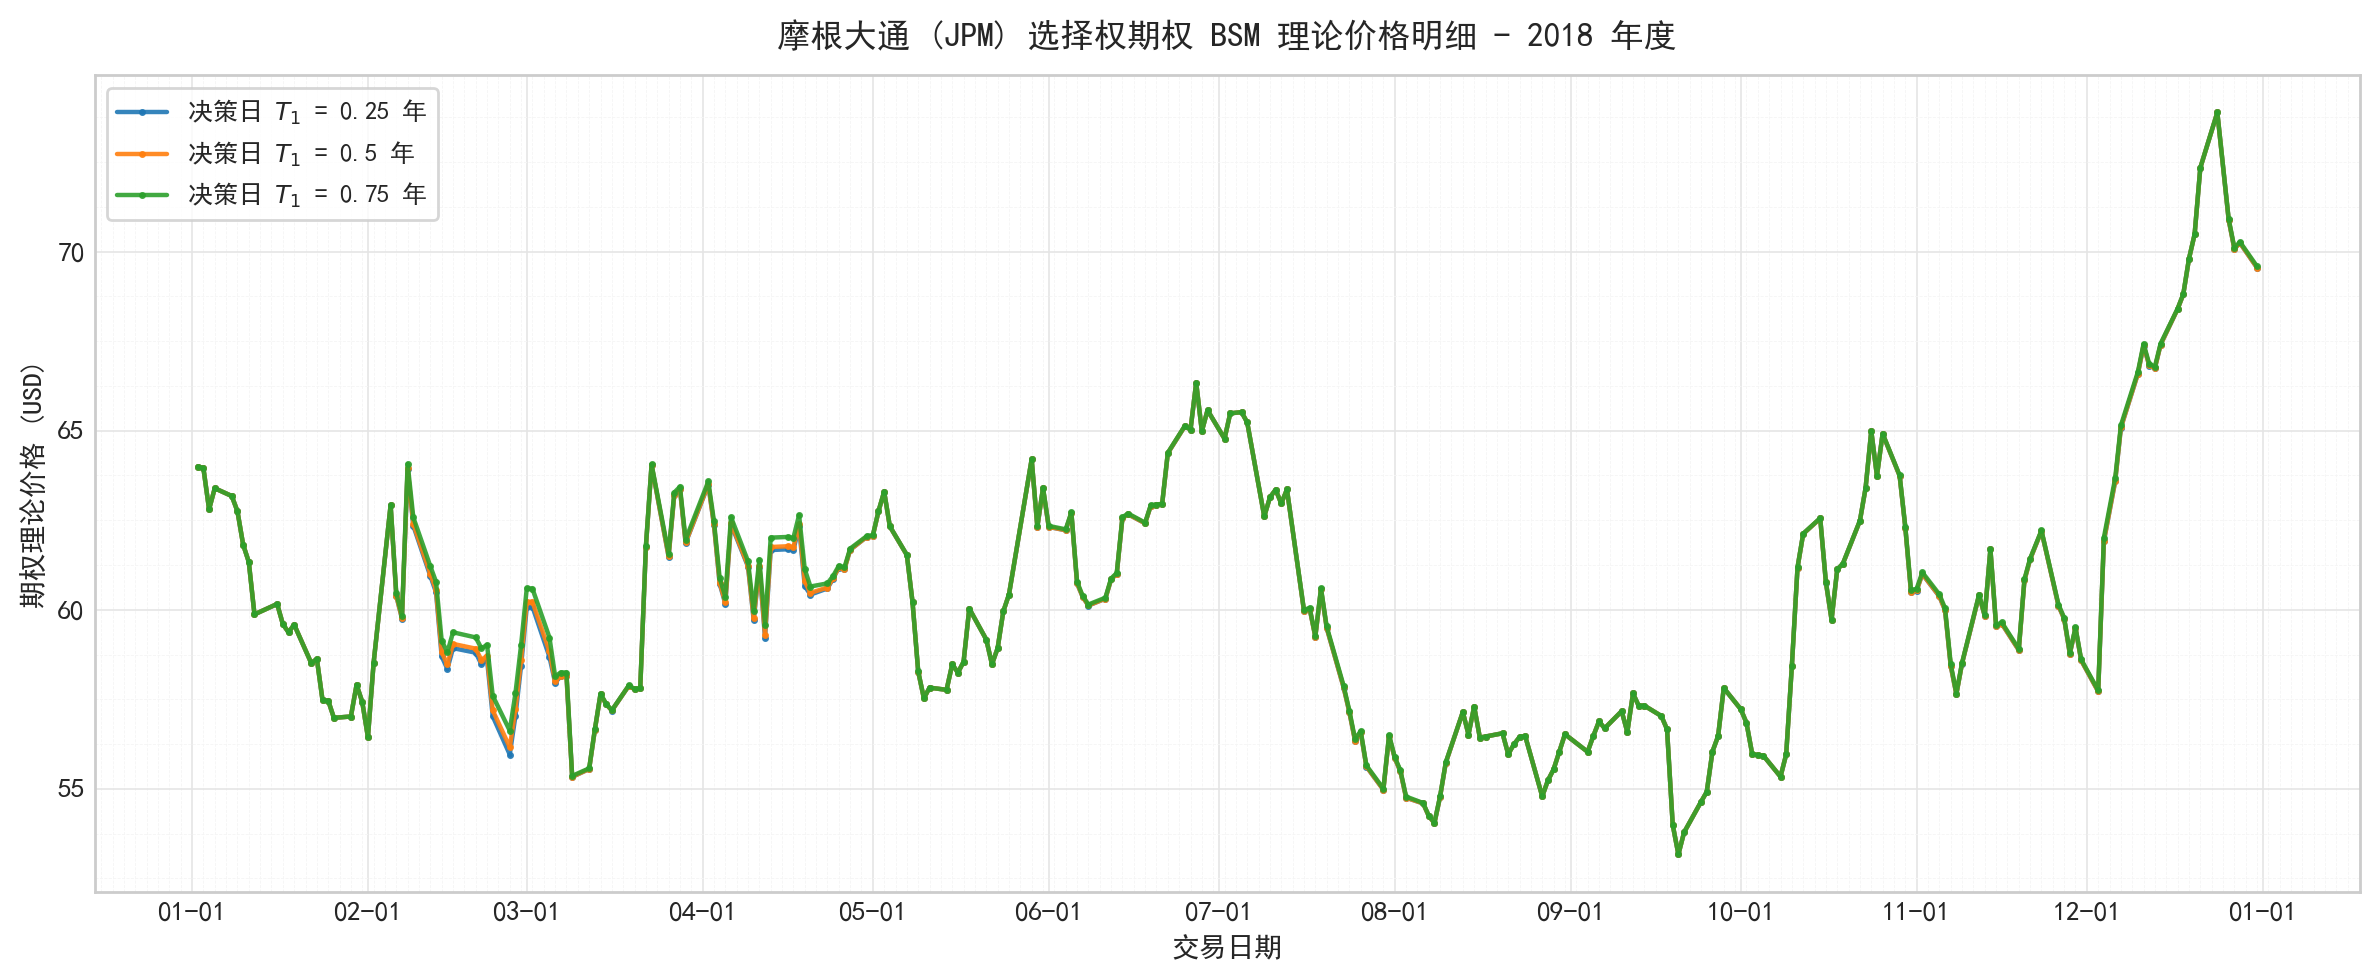

 -> 已成功导出 2018 年度高清图至: reports/figures/annual_scans/bsm_baseline_2018.png
------------------------------------------------------------


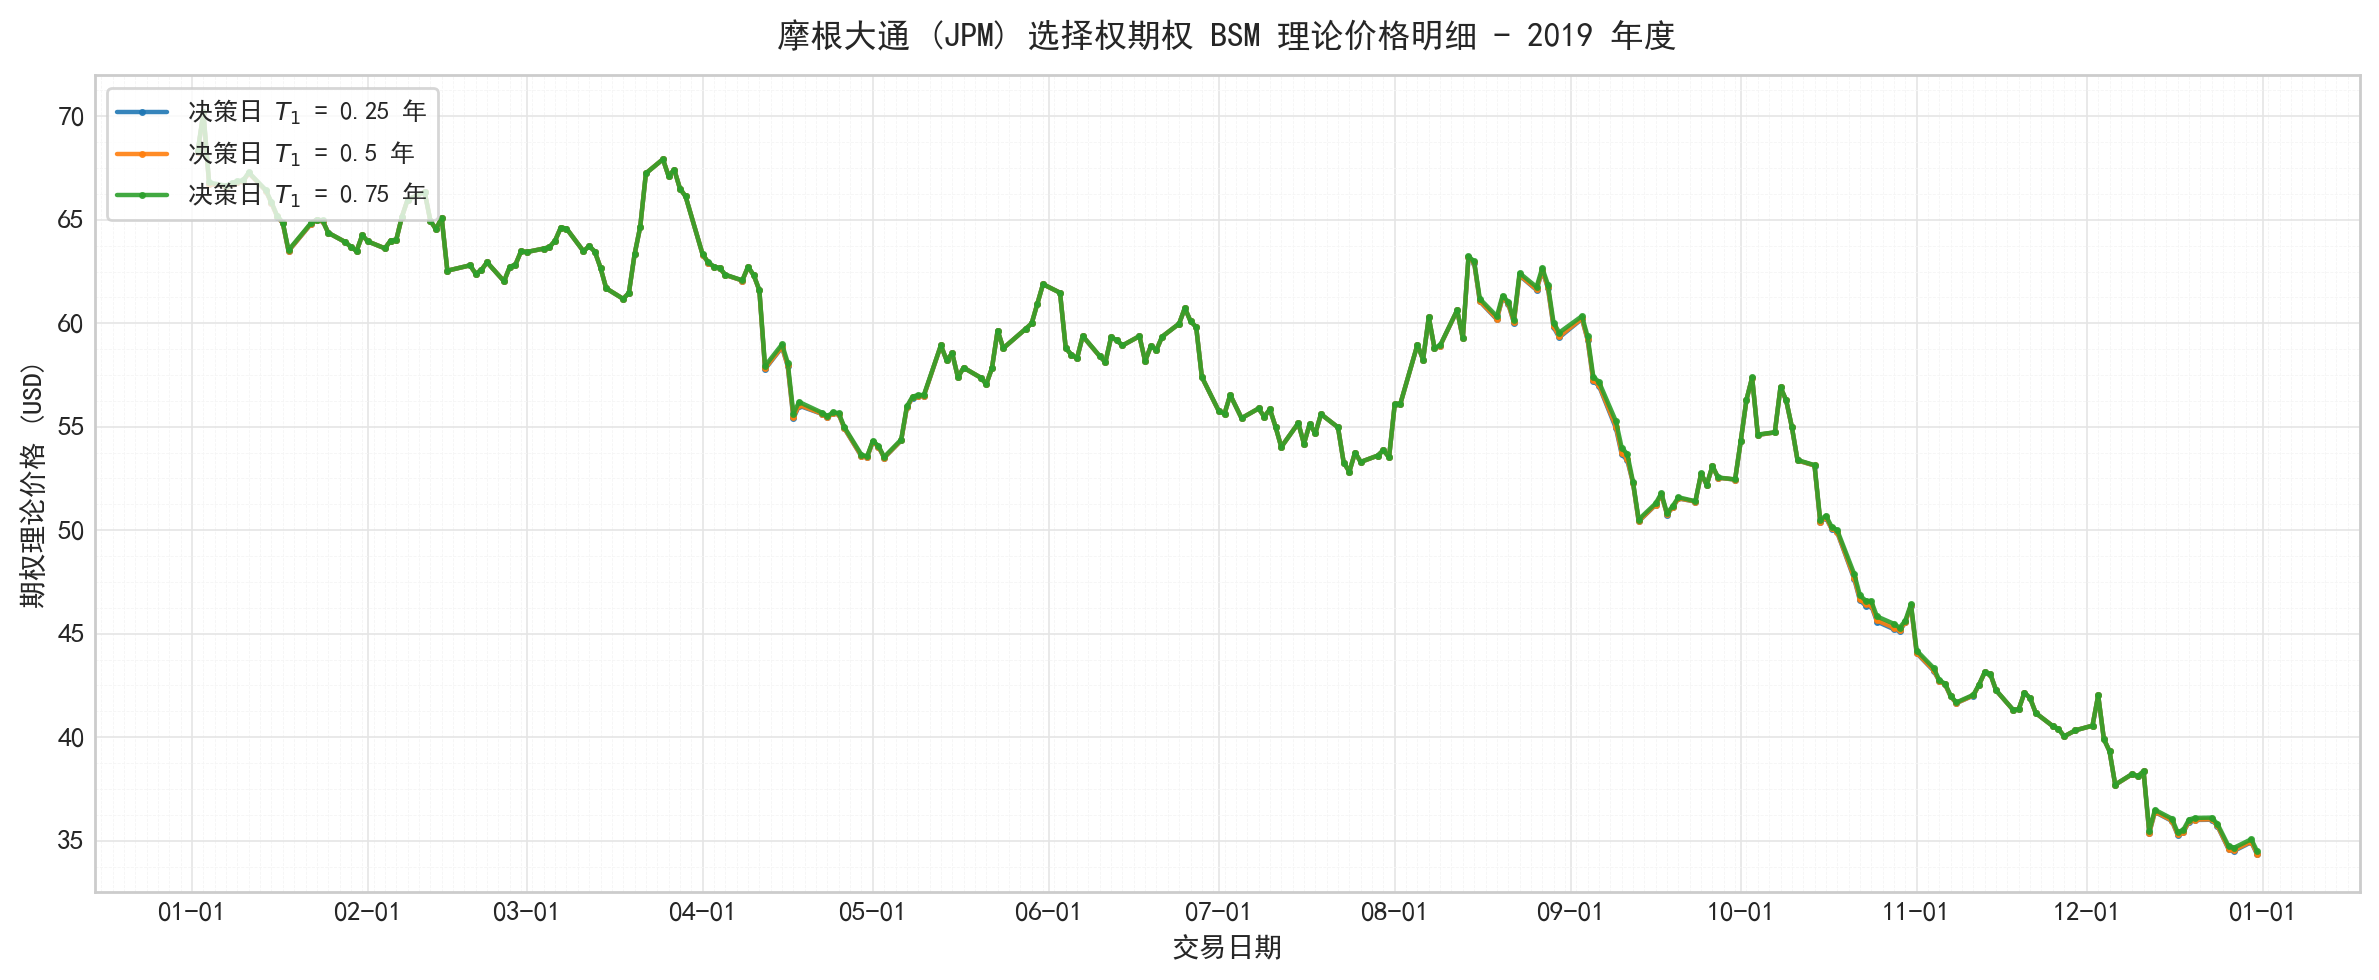

 -> 已成功导出 2019 年度高清图至: reports/figures/annual_scans/bsm_baseline_2019.png
------------------------------------------------------------


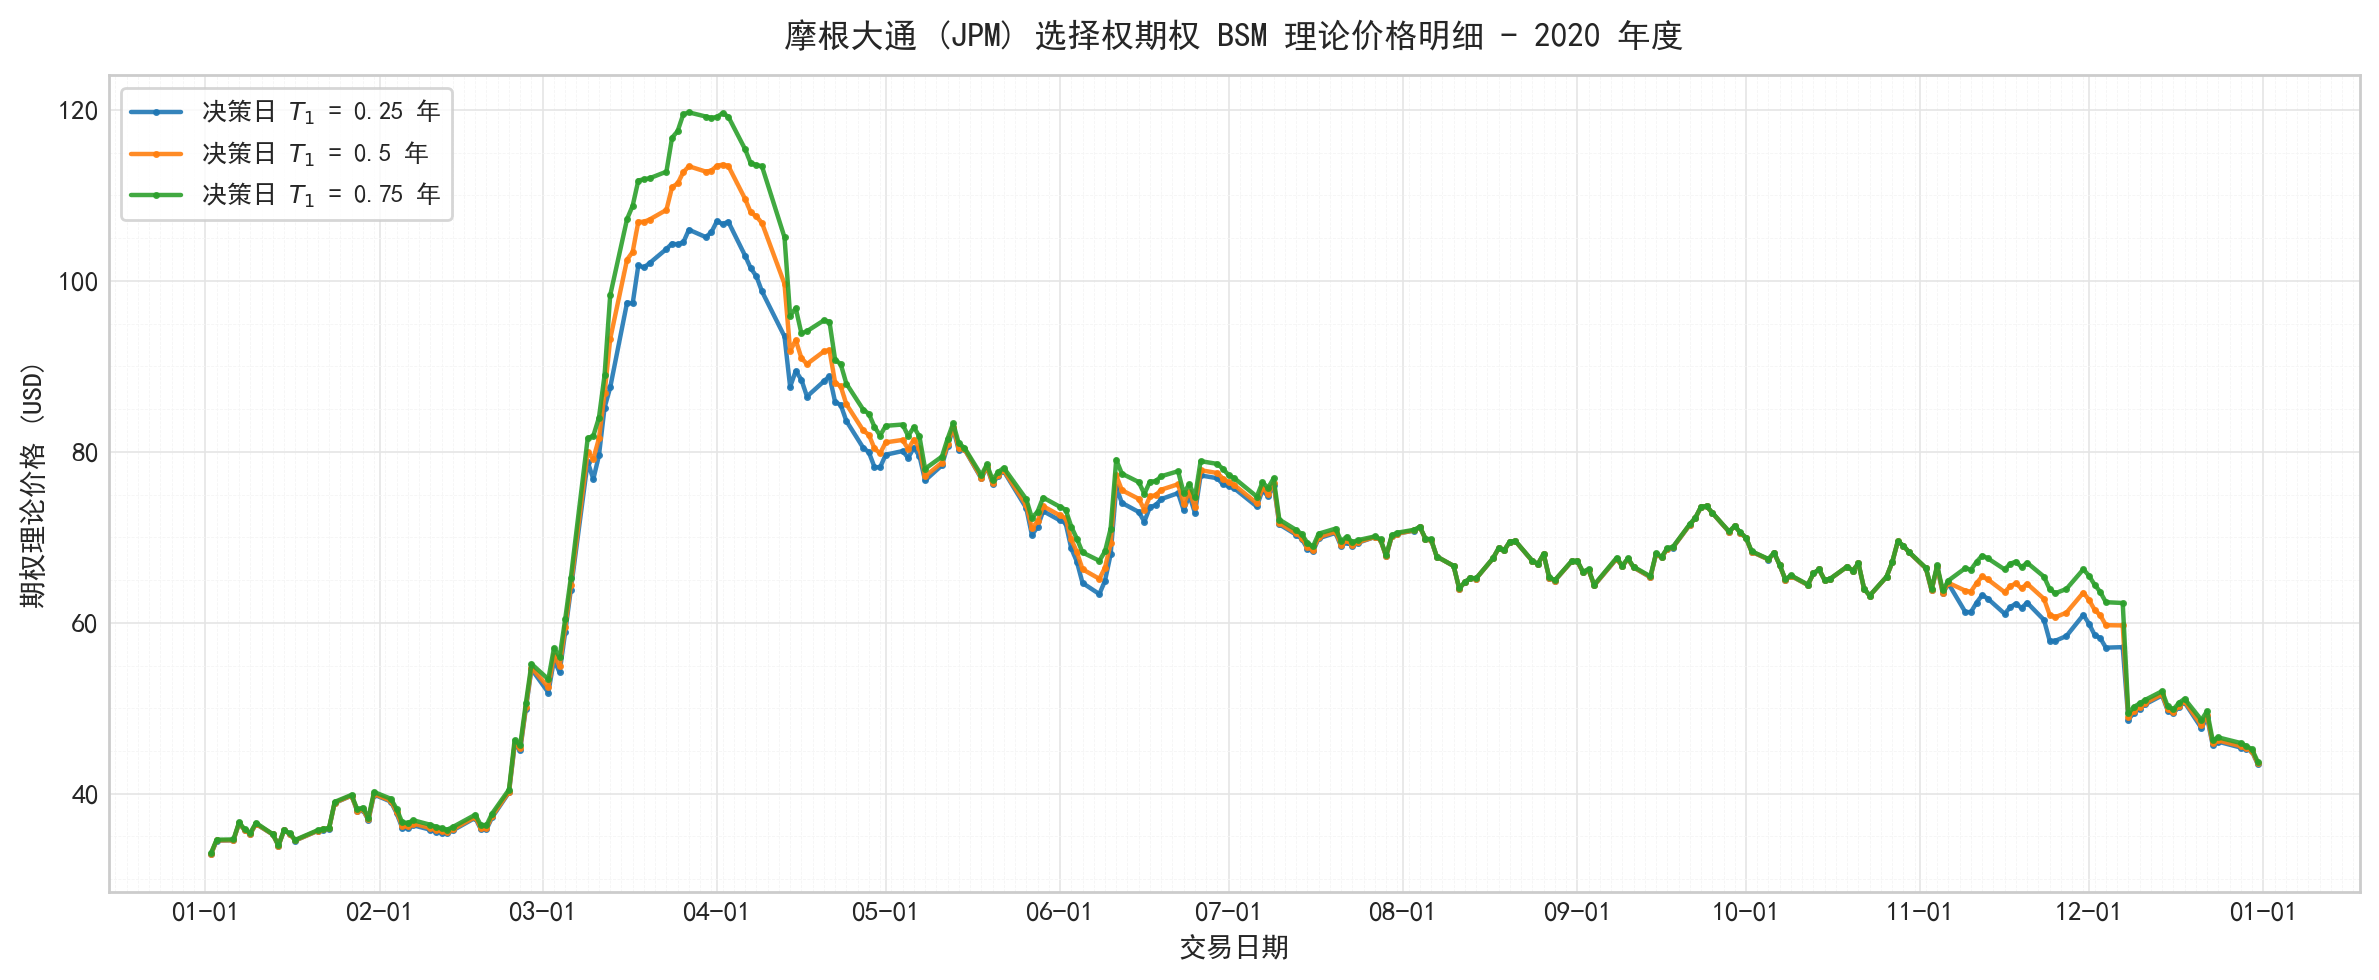

 -> 已成功导出 2020 年度高清图至: reports/figures/annual_scans/bsm_baseline_2020.png
------------------------------------------------------------


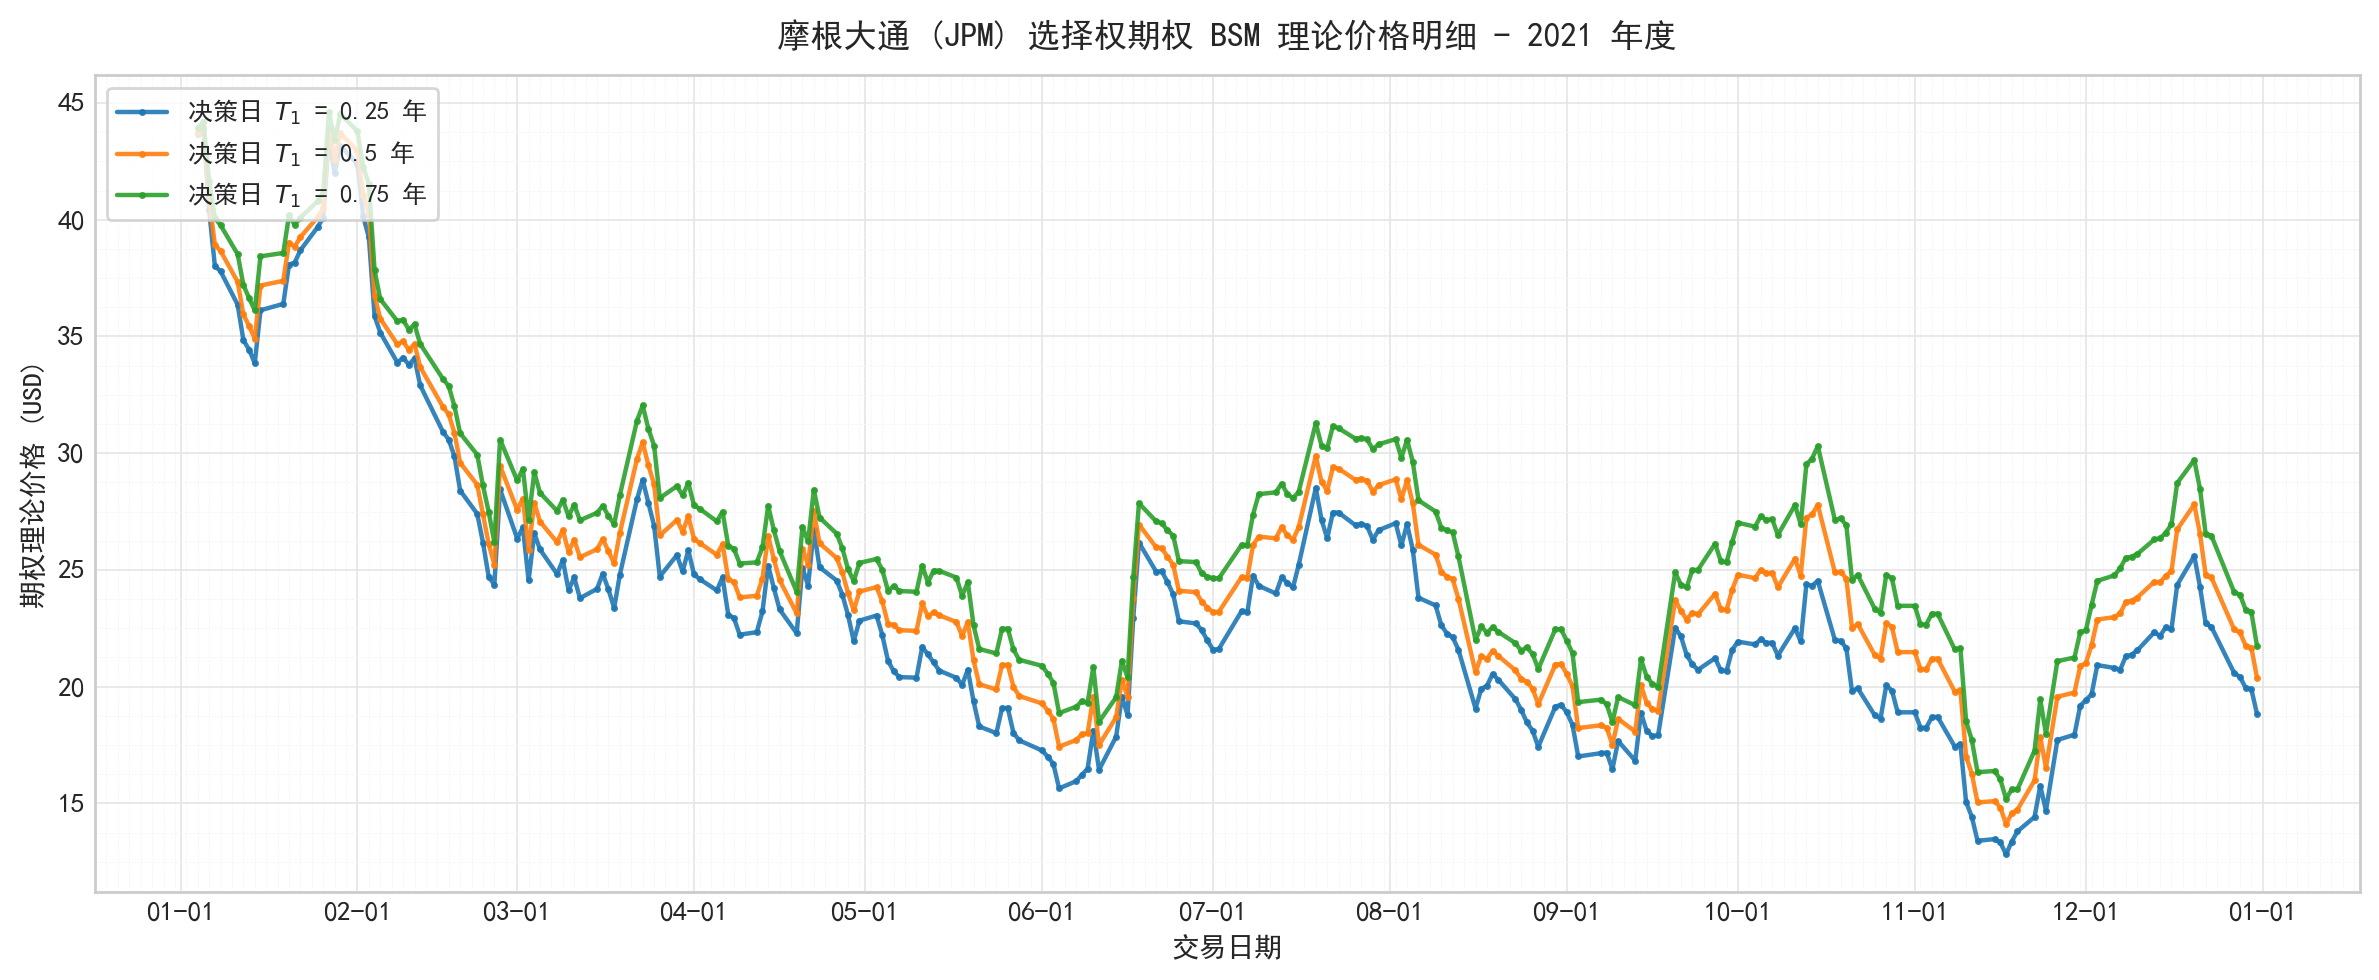

 -> 已成功导出 2021 年度高清图至: reports/figures/annual_scans/bsm_baseline_2021.png
------------------------------------------------------------


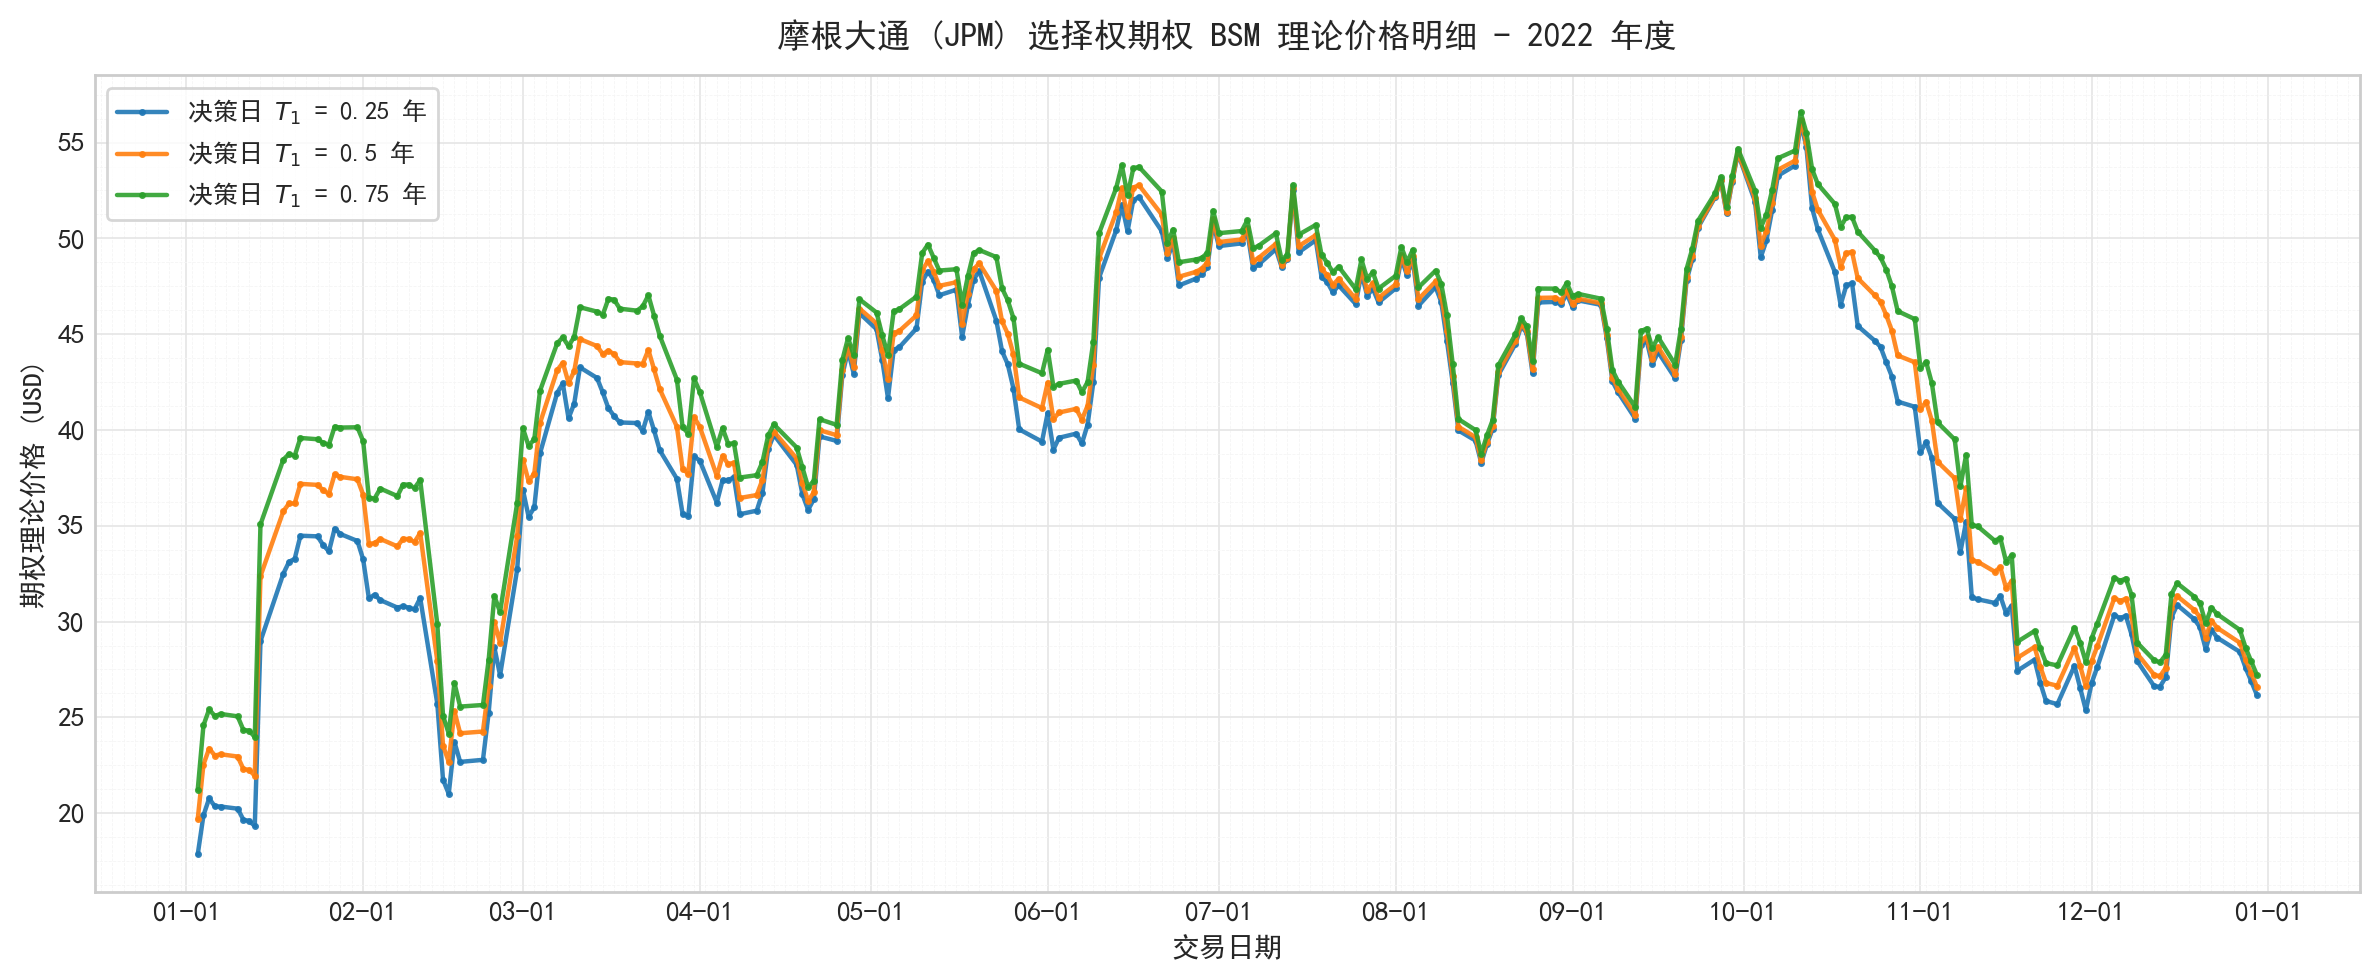

 -> 已成功导出 2022 年度高清图至: reports/figures/annual_scans/bsm_baseline_2022.png
------------------------------------------------------------


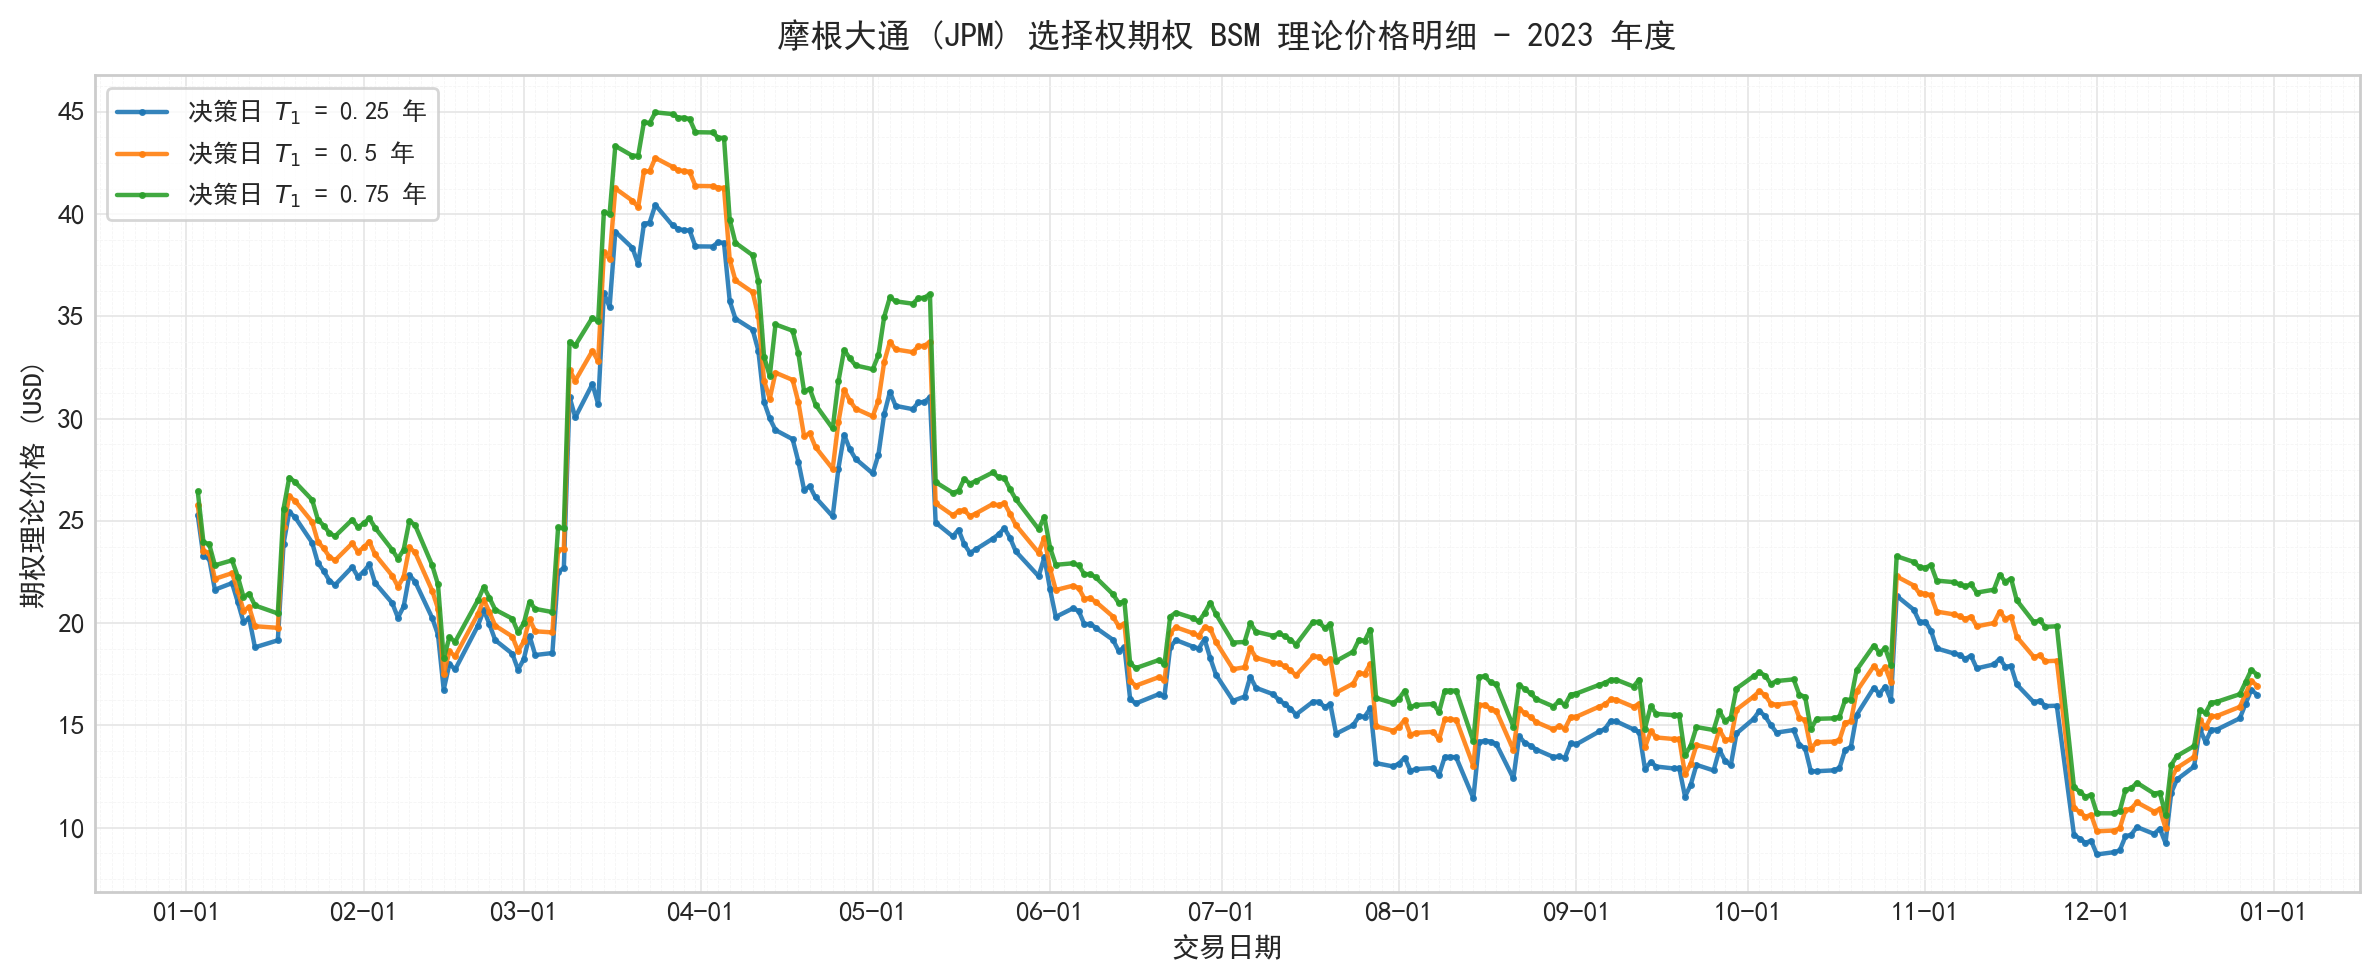

 -> 已成功导出 2023 年度高清图至: reports/figures/annual_scans/bsm_baseline_2023.png
------------------------------------------------------------


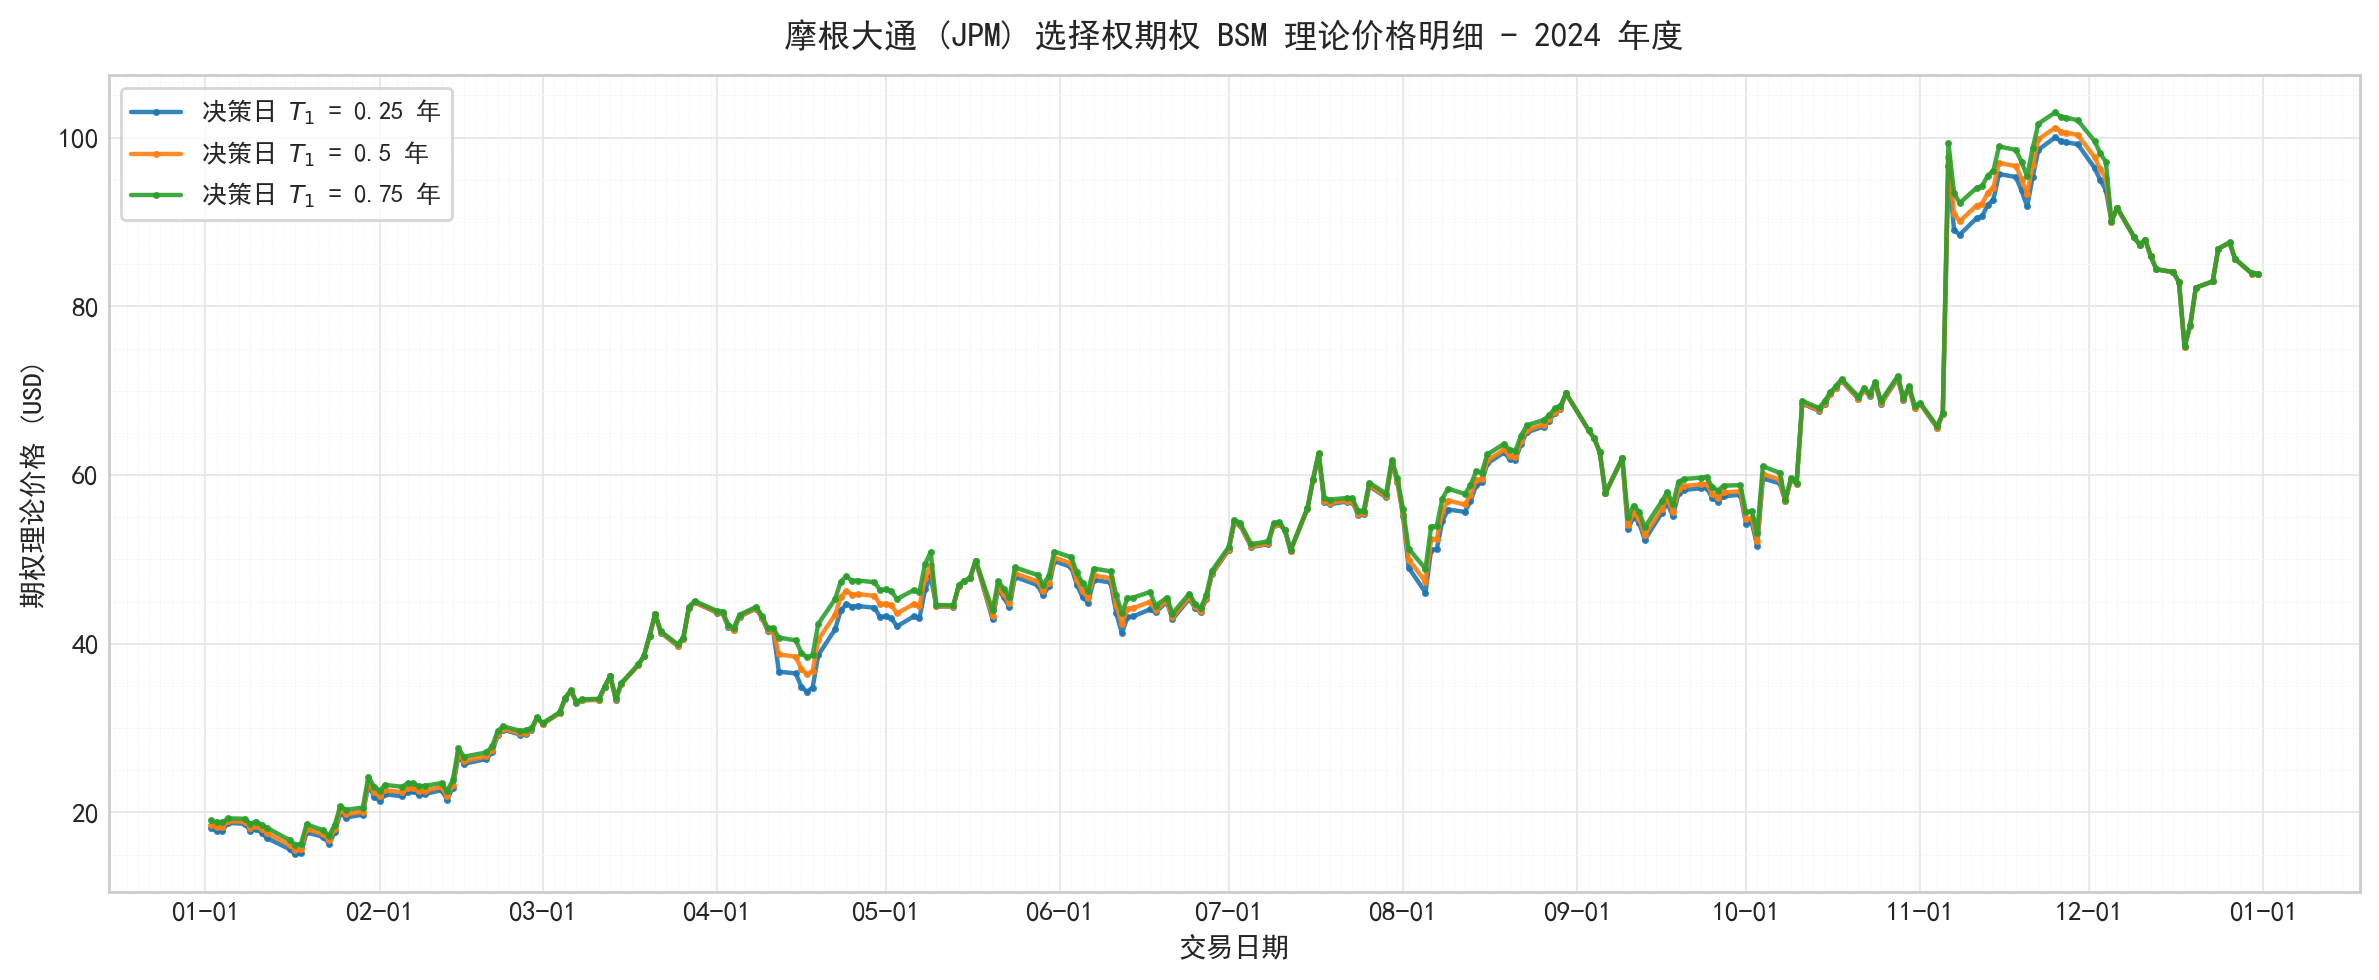

 -> 已成功导出 2024 年度高清图至: reports/figures/annual_scans/bsm_baseline_2024.png
------------------------------------------------------------


In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

# 1. 提取数据集里包含的所有独立年份 (2018 - 2026)
unique_years = sorted([y for y in df.index.year.unique() if 2018 <= y <= 2024])
print(f" 已成功锁定年度扫描队列（共 {len(unique_years)} 年）: {unique_years}")

T1_SCALES = [0.25, 0.5, 0.75]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 蓝、橙、绿

# 确保图片输出目录存在
os.makedirs("reports/figures/annual_scans", exist_ok=True)

# 2. 启动循环，为每一年单独建立高分辨率画布
for year in unique_years:
    # 抽取当前年份的增量切片
    df_year = df[df.index.year == year]
    
    if df_year.empty:
        continue
        
    # 为每一年分配独立的画布 (12x5 英寸，200 DPI 保证行内预览清晰)
    fig, ax = plt.subplots(figsize=(12, 5), dpi=200)
    
    # 循环绘制三条尺度线
    for t1, col in zip(T1_SCALES, colors):
        ax.plot(
            df_year.index, 
            df_year[f"Chooser_BSM_T1_{t1}"], 
            label=f"决策日 $T_1$ = {t1} 年", 
            color=col, 
            linewidth=1.6,
            marker='.',  # 增加数据点标记，防止折线太细
            markersize=3,
            alpha=0.9
        )
    
    # 精细化配置当前年份的标题与图例
    ax.set_title(f"摩根大通 (JPM) 选择权期权 BSM 理论价格明细 - {year} 年度", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("交易日期", fontsize=10)
    ax.set_ylabel("期权理论价格 (USD)", fontsize=10)
    ax.legend(loc="upper left", frameon=True, facecolor="white", fontsize=9)
    
    # 自适应配置横轴时间刻度：主刻度按月显示，次刻度每 2 天一划
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=2))
    
    # 纵轴自适应细分次级刻度线
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    
    # 开启高清双重极细网格线
    ax.grid(True, which='major', linestyle='-', linewidth=0.6, color='#e5e5e5')
    ax.grid(True, which='minor', linestyle='--', linewidth=0.3, color='#f5f5f5')
    
    # 优化布局并以 300 DPI 印刷级质量持久化到本地
    plt.tight_layout()
    file_save_path = f"reports/figures/annual_scans/bsm_baseline_{year}.png"
    plt.savefig(file_save_path, bbox_inches='tight', dpi=300)
    
    # 在 Notebook 界面中渲染出来供肉眼审查
    plt.show()
    print(f" -> 已成功导出 {year} 年度高清图至: {file_save_path}\n" + "-"*60)